In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# Load HGA

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        'PhonemeSequence',
        'TIMIT'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'
HGAs.head()

100%|██████████| 1925/1925 [01:36<00:00, 20.00it/s] 


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0024_LTG14-15,0.007910,False,STG,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_temp_sup-Lateral,-66.294399,-28.103954,7.090004
1,-1.0,D0024_LTG8-9,-0.001315,False,Intersection,L,D0024,Decision,LexicalNoDelay,stimulus,sound,Intersection,-55.427594,-7.961854,2.275063
2,-1.0,D0024_LTG5-6,0.026363,False,SMC,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,-65.187402,-14.882005,13.114168
3,-1.0,D0024_LTG12-13,0.088550,False,STG,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_temp_sup-Lateral,-65.771716,-8.370915,-2.009006
4,-1.0,D0024_LTG15-26,0.011030,False,Intersection,L,D0024,Decision,LexicalNoDelay,stimulus,sound,Intersection,-58.577098,-13.150433,-14.837984


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 432960
PIC electrode count: 385792


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0024_LTG14-15,0.007910,False,STG,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_temp_sup-Lateral,-66.294399,-28.103954,7.090004
1,-1.0,D0024_LTG8-9,-0.001315,False,Intersection,L,D0024,Decision,LexicalNoDelay,stimulus,sound,Intersection,-55.427594,-7.961854,2.275063
2,-1.0,D0024_LTG5-6,0.026363,False,SMC,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,-65.187402,-14.882005,13.114168
3,-1.0,D0024_LTG12-13,0.088550,False,STG,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_temp_sup-Lateral,-65.771716,-8.370915,-2.009006
4,-1.0,D0024_LTG15-26,0.011030,False,Intersection,L,D0024,Decision,LexicalNoDelay,stimulus,sound,Intersection,-58.577098,-13.150433,-14.837984


In [6]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        'PhonemeSequence',
        'TIMIT'
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
ZAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    ZAs.append(df)

ZAs = pd.concat(ZAs)

# rename both phase : Resp and Response to Resp
ZAs.loc[ZAs.phase == 'Resp', 'phase'] = 'Response'
ZAs.loc[ZAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
ZAs['phase'] = ZAs['phase'].str.lower()

# rename INS to 'Insula'
ZAs.loc[ZAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
ZAs.loc[ZAs.roi == 'PrG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'PoG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'Subcentral', 'roi'] = 'SMC'


ZAs.loc[ZAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
ZAs.loc[ZAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
ZAs.loc[ZAs.roi=='CG', 'roi'] = 'ACC'
ZAs.head()

100%|██████████| 1402/1402 [01:46<00:00, 13.14it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [7]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
ZAs['roi'] = ZAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(ZAs[ZAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(ZAs[ZAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = ZAs[ZAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
ZAs.head()

AIC electrode count: 986496
PIC electrode count: 874112


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


# AIC is only active during when action is required

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1000391/2070768144.py:43: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1000391/2070768144.py:43: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(


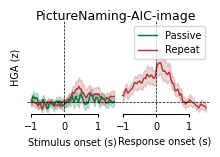

In [162]:
rois = ['PIC','AIC']
# tasks = ['LexicalDelay', 'LexicalNoDelay', 'PictureNaming', 'SentenceRep', 'PhonemeSequence']
# tasks = ['LexicalDelay', 'LexicalNoDelay','SentenceRep','PictureNaming','PhonemeSequence']
# descs = ['Passive','Repeat','Decision']

# tasks = ['PictureNaming', 'SentenceRep', 'LexicalNoDelay']
tasks = ['PictureNaming']
descs = ['Passive', 'Repeat']

# descs = ['Passive']

colors = ['#00753f', '#a9373b', '#5c4ebd']
modality = 'image'

subset = HGAs[
    (HGAs.task.isin(tasks))
    & (HGAs.roi.isin(rois))
    & (HGAs.hemi == 'L')
    & (~HGAs.subject.isin(['D0121','D0064','D0123','D0125','D0118']))
    # & (HGAs.description.isin(['Passive']))
    & (HGAs.modality==modality)
]

subset_z = ZAs[
    (ZAs.task.isin(tasks))
    & (ZAs.channel.isin(subset.channel.unique()))
    & (ZAs.hemi == 'L')
    & (ZAs.time<1.5)
    & (ZAs.description.isin(descs))
    & (~ZAs.subject.isin(['D0121','D0064','D0123','D0125','D0129','D0118']))
    & (ZAs.modality==modality)
]

phases = ['stimulus', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset_z[(subset_z.phase == phase)],
        x='time',
        y='value',
        hue='description',
        hue_order=descs,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 0.8)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)
    
plt.suptitle(f'PictureNaming-AIC-{modality}', fontsize=9)
plt.savefig(f'../img/misc/compare_across_conditions_{rois[0]}_picturenaming_{modality}.svg', dpi=300, bbox_inches='tight')
plt.show()

## Spatial

In [163]:
desc = 'Passive'
spatial = subset_z[
    (subset_z.phase == 'stimulus')
    & (subset_z.description == desc)
    & (subset_z.modality == 'image')
    & (subset_z.time>0)
    & (subset_z.time<1)
    ].groupby('channel').agg({
    'value': 'max',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0079_LPI8-9,0.485361,-34.099114,-9.593679,14.044702,AIC,ctx_lh_G_insular_short,stimulus,L,D0079,Passive,PictureNaming
1,D0079_LPI9-10,0.506487,-33.808683,-9.618793,17.534018,PIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0079,Passive,PictureNaming
2,D0080_LAI4-5,0.393574,-33.557218,15.008318,-0.804909,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0080,Passive,PictureNaming
3,D0080_LAI5-6,0.336401,-33.399199,16.642277,2.455954,AIC,ctx_lh_G_insular_short,stimulus,L,D0080,Passive,PictureNaming
4,D0080_LAI6-7,0.716210,-32.992777,18.329265,5.976038,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0080,Passive,PictureNaming


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


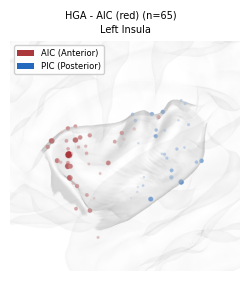

In [165]:
# ============================================================
# 3D Insula HGA Visualization - AIC (red) vs PIC (blue)
# 保持与 Cell 13 完全相同的参数，只改变颜色
# ============================================================

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
# vmin, vmax = 0, np.percentile(hga_values, 95)
vmin, vmax = 0, 1
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 5, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 1, figsize=(8*cm, 8*cm))

axes.imshow(lh_brain.screenshot(mode="rgb"))
axes.axis("off")
axes.set_title("Left Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes.legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("HGA - AIC (red) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)

plt.savefig(f'../img/misc/condition_difference_spatial_{rois[0]}_{desc}_picturenaming.svg', dpi=300, bbox_inches='tight')

## Barplot of comparsion

In [103]:
spatial = subset_z[
    (subset_z.phase == 'stimulus')
    & (subset_z.modality == 'sound')
    & (subset_z.time>0)
    & (subset_z.time<0.5)
    ].groupby(['channel','description']).agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,description,HGA,x,y,z,roi,label,phase,hemi,subject,task
0,D0027_LAI2-3,Decision,-0.004806,-32.470676,9.175895,4.597974,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0027,LexicalNoDelay
1,D0027_LAI2-3,Passive,-0.025414,-32.470676,9.175895,4.597974,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0027,LexicalNoDelay
2,D0027_LAI2-3,Repeat,0.079013,-32.470676,9.175895,4.597974,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0027,LexicalNoDelay
3,D0027_LAI3-4,Decision,0.064556,-30.700923,13.124481,11.623351,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0027,LexicalNoDelay
4,D0027_LAI3-4,Passive,0.015538,-30.700923,13.124481,11.623351,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0027,LexicalNoDelay


/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


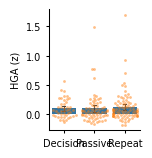

In [104]:
fig, ax = plt.subplots(1, 1, figsize=(3*cm, 4*cm))

sns.barplot(
    data=spatial,
    x='description',
    y='HGA',
    errorbar=('ci', 95),
    capsize=0.1,     
    errwidth=0.75,
    ax=ax,
)

sns.swarmplot(data=spatial, 
            x="description", 
            y="HGA", 
            dodge=True,
            size=2,
            alpha=0.5,
            ax=ax,
            legend=False,)

ax.set_xlabel('')
ax.set_ylabel('HGA (z)', fontsize=7)

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both',)
    plt.setp(ax.spines.values(), linewidth=.75)
    
sns.despine()

# Common electrodes in Lexical Delay and no delay

In [172]:
subset = HGAs[
    HGAs.task.isin(['LexicalDelay','LexicalNoDelay'])
]

subset['significance'] = subset.groupby(['channel'])['mask'].transform('any')

subset = subset[subset.significance == True]

common_channels = (subset[subset.task == 'LexicalDelay']['channel']
                  .unique())

common_channels = np.intersect1d(
    common_channels,
    subset[subset.task == 'LexicalNoDelay']['channel'].unique()
)

subset_common = subset[subset.channel.isin(common_channels)]

subset_common.head()

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1000391/1629874323.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['significance'] = subset.groupby(['channel'])['mask'].transform('any')


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z,significance
0,-1.0,D0024_LTG14-15,0.007910,False,STG,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_temp_sup-Lateral,-66.294399,-28.103954,7.090004,True
1,-1.0,D0024_LTG8-9,-0.001315,False,Intersection,L,D0024,Decision,LexicalNoDelay,stimulus,sound,Intersection,-55.427594,-7.961854,2.275063,True
2,-1.0,D0024_LTG5-6,0.026363,False,SMC,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,-65.187402,-14.882005,13.114168,True
3,-1.0,D0024_LTG12-13,0.088550,False,STG,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_temp_sup-Lateral,-65.771716,-8.370915,-2.009006,True
4,-1.0,D0024_LTG15-26,0.011030,False,Intersection,L,D0024,Decision,LexicalNoDelay,stimulus,sound,Intersection,-58.577098,-13.150433,-14.837984,True


In [173]:
subset_common[subset_common.roi=='AIC'].subject.unique()

array(['D0028', 'D0071', 'D0092', 'D0094', 'D0128'], dtype=object)

In [174]:
subset_common[(subset_common.roi=='AIC') & (subset_common.hemi=='L')].subject.unique()

array(['D0028', 'D0092', 'D0094'], dtype=object)

# Decision>Repeat>Passive

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1000391/3408502964.py:22: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1000391/3408502964.py:22: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(


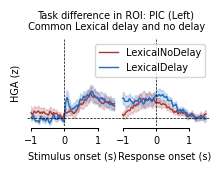

In [196]:
rois = ['PIC','AIC']
tasks = subset_common.task.unique()
descs = subset_common.description.unique()

colors = [red, blue, green]

subset_ = subset_common[
    (subset_common.roi.isin(rois))
    & (subset_common.hemi == 'L')
]


phases = ['stimulus', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset_[(subset_.phase == phase)],
        x='time',
        y='value',
        hue='task',
        hue_order=tasks,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)

plt.subplots_adjust(top=0.85)

plt.suptitle(f'Task difference in ROI: {rois[0]} (Left)'
             '\n Common Lexical delay and no delay', 
             fontsize=7, y=1.1)

plt.savefig(f'../img/misc/lexical_task_diff_{rois[0]}.svg', dpi=300, bbox_inches='tight')
plt.show()

In [198]:
spatial = subset_[
    (subset_.phase == 'stimulus')
    & (subset_.description == 'Decision')
    & (subset_.time>0)
    & (subset_.time<1)
    ].groupby('channel').agg({
    'value': 'max',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0028_LAI1-2,0.398116,-34.700069,8.872246,-13.792580,AIC,ctx_lh_G_insular_short,stimulus,L,D0028,Decision,LexicalNoDelay
1,D0028_LAI3-4,0.329001,-34.543239,15.001830,0.344973,AIC,ctx_lh_G_insular_short,stimulus,L,D0028,Decision,LexicalNoDelay
2,D0092_LIA3-4,0.495201,-32.327604,20.570610,-0.181530,AIC,ctx_lh_G_insular_short,stimulus,L,D0092,Decision,LexicalNoDelay
3,D0092_LIA4-5,0.868136,-31.395989,23.017292,3.544917,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0092,Decision,LexicalNoDelay
4,D0092_LIA5-6,0.965641,-30.464373,25.463973,7.271363,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0092,Decision,LexicalNoDelay


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


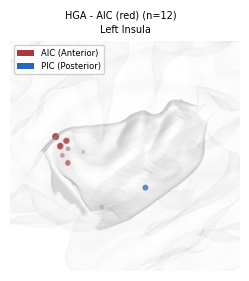

In [200]:
# ============================================================
# 3D Insula HGA Visualization - AIC (red) vs PIC (blue)
# 保持与 Cell 13 完全相同的参数，只改变颜色
# ============================================================

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
# vmin, vmax = 0, np.percentile(hga_values, 95)
vmin, vmax = 0, 1
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 1, figsize=(8*cm, 8*cm))

axes.imshow(lh_brain.screenshot(mode="rgb"))
axes.axis("off")
axes.set_title("Left Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes.legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("HGA - AIC (red) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)
plt.savefig(f'../img/misc/condition_difference_spatial_{rois[0]}.svg', dpi=300, bbox_inches='tight')

## Same stimulus, different output (button press vs. repeat) 

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1000391/1389367088.py:23: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1000391/1389367088.py:23: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(


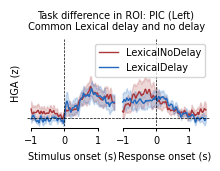

In [195]:
rois = ['PIC','AIC']
tasks = subset_common.task.unique()
descs = subset_common.description.unique()

colors = [red, blue, green]

subset_ = subset_common[
    (subset_common.roi.isin(rois))
    & (subset_common.hemi == 'L')
    & (subset_common.description == 'Decision')
]


phases = ['stimulus', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset_[(subset_.phase == phase)],
        x='time',
        y='value',
        hue='task',
        hue_order=tasks,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)

plt.subplots_adjust(top=0.85)

plt.suptitle(f'Task difference in ROI: {rois[0]} (Left)'
             '\n Common Lexical delay and no delay', 
             fontsize=7, y=1.1)

# plt.savefig(f'../img/misc/lexical_task_diff_{rois[0]}.svg', dpi=300, bbox_inches='tight')
plt.show()

# AIC represent saliance

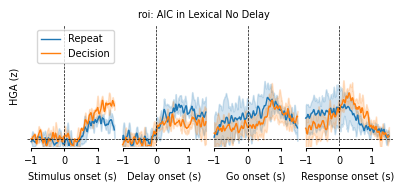

In [ ]:
rois = ['AIC',]
colors = [red, blue]

subset = HGAs[
    # (HGAs.task == 'LexicalDelay')
    # (HGAs.roi.isin(rois))
    (HGAs.label.str.contains('Opercular'))
    & (HGAs.subject != 'D0121')
    # & (HGAs.hemi == 'L')
    & (HGAs.modality == 'sound')
    # & (HGAs.description != 'Mime')
]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

for (ax, phase) in zip(fig.axes, ['stimulus', 'delay', 'go', 'response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    
    line = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='description',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    ax.set_ylim(-0.1, 1.2)


for ax in fig.axes:
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

plt.suptitle('roi: ' + rois[0] + ' in Lexical No Delay', fontsize=7)
# plt.savefig('../img/fig1/fig1_AIPI_temporal_PictureNaming.svg', dpi=300, bbox_inches='tight')
plt.show()

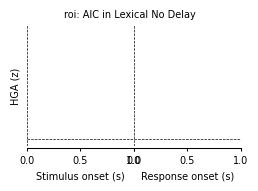

In [9]:
rois = ['AIC']
colors = [red, blue]

subset = HGAs[
    (HGAs.task == 'LexicalNoDelay')
    & (HGAs.roi.isin(rois))
    & (HGAs.subject != 'D0121')
    & (HGAs.hemi == 'L')
    # & (HGAs.modality == 'sound')
    & (HGAs.description != 'Mime')
]

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(7*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5]})

plt.subplots_adjust(wspace=0)

for (ax, phase) in zip(fig.axes, ['stimulus', 'response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    
    line = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='description',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    ax.set_ylim(-0.1, 1.2)



for ax in fig.axes:
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)

plt.suptitle('roi: ' + rois[0] + ' in Lexical No Delay', fontsize=7)
# plt.savefig('../img/fig1/fig1_AIPI_temporal_PictureNaming.svg', dpi=300, bbox_inches='tight')
plt.show()

# Ave across channels: to get the significant clusters in a ROI

In [21]:
bids_root = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'

In [17]:
# load label array
phases = ['Stimulus', 'Delay', 'Go', 'Response']
conditions = ['Decision','Repeat']

epos = []

for phase in tqdm(phases):
    
    for sub in subset.subject.unique():
        
        picks = subset[subset.subject==sub].channel.unique().tolist()
        
        pt = BIDSPath(
            root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
            subject=sub,
            datatype='epoch(band)(zscore)',
            processing=phase,
            suffix='highgamma',
            extension='.h5',
            check=False
        )

        for condition in conditions:
            epo_path = pt.update(description=condition).match()[0]
            dc_epo = mne.read_epochs(epo_path, verbose='error')
            dc_epo.pick(picks)
            data = dc_epo.get_data()            # (trial, channel, time)
            times = dc_epo.times

            mean_ch = data.mean(axis=1)         # (trial, time)
            trial_ids = [f"{sub}_trial{i}" for i in range(mean_ch.shape[0])]
            df = pd.DataFrame(mean_ch, columns=times)
            df['trial'] = trial_ids
            df = df.melt(id_vars=['trial'], var_name='time', value_name='value')
            df['condition'] = condition
            df['phase'] = phase.lower()
            df['subject'] = sub
            epos.append(df)

epos = pd.concat(epos, ignore_index=True)
epos.head()

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:59<00:00, 14.92s/it]


,trial,time,value,condition,phase,subject
0,D0023_trial0,-1.0,0.347707,Decision,stimulus,D0023
1,D0023_trial1,-1.0,-0.195837,Decision,stimulus,D0023
2,D0023_trial2,-1.0,-0.089345,Decision,stimulus,D0023
3,D0023_trial3,-1.0,1.248313,Decision,stimulus,D0023
4,D0023_trial4,-1.0,-0.029512,Decision,stimulus,D0023


In [18]:
from ieeg.calc.stats import time_perm_cluster

perms = []

for phase in tqdm(phases):
    # 保留 trial，先按 channel 平均得到 (trial, time)
    dec_df = epos[(epos.condition == 'Decision') & (epos.phase == phase.lower())]
    rep_df = epos[(epos.condition == 'Repeat') & (epos.phase == phase.lower())]
    # pivot to (trial x time)
    decision = dec_df.pivot(index='trial', columns='time', values='value').sort_index(axis=1)
    repeat   = rep_df.pivot(index='trial', columns='time', values='value').sort_index(axis=1)

    # 置换检验：trial 为观测，time 为维度
    mask, p = time_perm_cluster(
        decision.values,
        repeat.values,
        p_thresh=0.05,
        n_perm=2000,
        n_jobs=-1
    )
    times = decision.columns.values

    df = pd.DataFrame({
        'time': times,
        'mask': mask,
        'pval': p,
        'phase': phase.lower()
    })
    perms.append(df)
        
perms = pd.concat(perms, ignore_index=True)
perms.head()

100%|██████████| 4/4 [05:56<00:00, 89.10s/it]


,time,mask,pval,phase
0,-1.000000,False,0.217891,stimulus
1,-0.992188,False,0.187406,stimulus
2,-0.984375,False,0.175912,stimulus
3,-0.976562,False,0.157921,stimulus
4,-0.968750,False,0.143928,stimulus


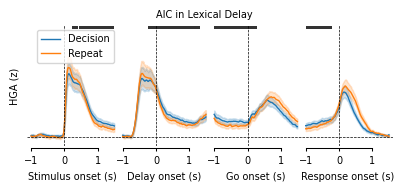

In [22]:
colors = [red, blue]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

for (ax, phase) in zip(fig.axes, ['stimulus', 'delay', 'go', 'response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    mask = perms.loc[perms.phase == phase, 'mask'].values
    pvals = perms.loc[perms.phase == phase, 'pval'].values
    
    line = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='description',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    # set a consistent y-range first
    ax.set_ylim(-0.1, 1.2)
    ymin, ymax = ax.get_ylim()
    pad = 0.01 * (ymax - ymin)
    bar_h = 0.02 * (ymax - ymin)

    times = perms.loc[perms.phase == phase, 'time'].values
    sig = (mask.astype(bool)) & (pvals < 0.05)

    if sig.any():
        ax.fill_between(
            times,
            ymax + pad,
            ymax + pad + bar_h,
            where=sig,
            color='k',
            alpha=0.8,
            step='mid',
            linewidth=0
        )

    ax.set_ylim(ymin, ymax + pad + bar_h + 0.01*(ymax - ymin))


for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

plt.suptitle(rois[0] + ' in Lexical Delay', fontsize=7)
plt.savefig(f'../img/fig4/fig4_{rois[0]}_condition_difference.svg', dpi=300, bbox_inches='tight')
plt.show()

# Univariate analysis: HGA difference on the repeat vs. Decsion Level

In [9]:
bids_root = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'

In [10]:
subset = HGAs[
    (HGAs.roi.isin(['PIC','AIC','STG','SMC','dACC',
                    'ITG','SMG','MTG','IFG','SFG',
                    'MFG','STS','AG','SPL','IPL',
                    'HG']) 
    & (HGAs.task == 'LexicalDelay'))
]
subset.head()

,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
7,-1.000000,D0023_RPIF8-9,0.532667,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,59.983127,-31.909288,20.181224
10,-1.000000,D0023_RPIF9-10,0.181906,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,63.592048,-32.361872,20.761790
19,-0.992188,D0023_RPIF8-9,0.498545,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,59.983127,-31.909288,20.181224
22,-0.992188,D0023_RPIF9-10,0.158769,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,63.592048,-32.361872,20.761790
31,-0.984375,D0023_RPIF8-9,0.455962,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,59.983127,-31.909288,20.181224


In [11]:
import re

# load label array
phases = ['Stimulus', 'Delay', 'Go', 'Response']
conditions = ['Decision','Repeat']

epos = []

for phase in tqdm(phases):
    
    for sub in subset.subject.unique():
        
        picks = subset[subset.subject==sub].channel.unique().tolist()
        
        pt = BIDSPath(
            root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
            subject=sub,
            datatype='epoch(band)(zscore)',
            processing=phase,
            suffix='highgamma',
            extension='.h5',
            check=False
        )

        for condition in conditions:
            epo_path = pt.update(description=condition).match()[0]
            dc_epo = mne.read_epochs(epo_path, verbose='error')
            dc_epo.pick(picks)
            df = dc_epo.to_data_frame(long_format=True, verbose='error')
            # 平均 channel，保留 trial 作为观测
            # df['condition'] = df['condition'].str.extract(r'(Word|Nonword)/[^/]+')
            df['condition'] = df['condition'].str.split('/').str[2:4].str.join('/')
            df['description'] = condition
            df['phase'] = phase.lower()
            df['subject'] = sub
            epos.append(df)

epos = pd.concat(epos, ignore_index=True)
epos.head()

100%|██████████| 4/4 [06:59<00:00, 104.90s/it]


,condition,epoch,time,channel,ch_type,value,description,phase,subject
0,Word/latin,1,-1.0,D0023_RPIF8-9,seeg,1199.448943,Decision,stimulus,D0023
1,Word/latin,1,-1.0,D0023_RPIF9-10,seeg,-129.327744,Decision,stimulus,D0023
2,Word/latin,1,-1.0,D0023_R2IF1-2,seeg,-705.475986,Decision,stimulus,D0023
3,Word/latin,1,-1.0,D0023_R2MF10-11,seeg,-53.457052,Decision,stimulus,D0023
4,Word/latin,1,-1.0,D0023_R2MF9-10,seeg,-130.285442,Decision,stimulus,D0023


In [12]:
from ieeg.calc.stats import time_perm_cluster

perms = []

for phase in tqdm(phases):
   
    des = epos[(epos.description == 'Decision') & (epos.phase == phase.lower())]
    rep = epos[(epos.description == 'Repeat') & (epos.phase == phase.lower())]
    
    decision_da = (des
        .groupby(['condition','channel','time'])['value']
        .mean() 
        .to_xarray()
    )
    repeat_da = (rep
        .groupby(['condition','channel','time'])['value']
        .mean() 
        .to_xarray()
    )
    
    
    # decision>repeat
    mask, p = time_perm_cluster(
        decision_da.values,
        repeat_da.values,
        p_thresh=0.05,
        ignore_adjacency=1,
        n_perm=1000,
        n_jobs=10
    )
    
    # mask, p = time_perm_cluster(
    #     repeat_da.values,
    #     decision_da.values,
    #     p_thresh=0.05,
    #     ignore_adjacency=1,
    #     n_perm=1000,
    #     n_jobs=10
    # )
    
    times = repeat_da.time.values
    channels = repeat_da.channel.values

    df = pd.DataFrame({
        'channel': np.repeat(channels, len(times)),
        'time': np.tile(times, len(channels)),
        'mask': mask.ravel(),
        'p': p.ravel(),
        'phase': phase.lower()
    })
    perms.append(df)
        
perms = pd.concat(perms, ignore_index=True)
perms.head()

  0%|          | 0/4 [00:00<?, ?it/s][Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=10)]: Done   2 tasks      | elapsed:    0.9s
[Parallel(n_jobs=10)]: Done   3 tasks      | elapsed:    1.0s
[Parallel(n_jobs=10)]: Done   4 tasks      | elapsed:    1.0s
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:    1.1s
[Parallel(n_jobs=10)]: Done   6 tasks      | elapsed:    1.2s
[Parallel(n_jobs=10)]: Done   7 tasks      | elapsed:    1.2s
[Parallel(n_jobs=10)]: Done   8 tasks      | elapsed:    1.2s
[Parallel(n_jobs=10)]: Done   9 tasks      | elapsed:    1.2s
[Parallel(n_jobs=10)]: Done  10 tasks      | elapsed:    1.3s
[Parallel(n_jobs=10)]: Done  11 tasks      | elapsed:    1.4s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:    1.4s
[Parallel(n_jobs=10)]: Done  13 tasks      | elapsed:    1.8s
[Parallel(n_jobs=10)]: Done  14 tasks      | elapsed:    1.8s
[Parallel(n_j

,channel,time,mask,p,phase
0,D0023_R1MF1-2,-1.000000,0,0.605395,stimulus
1,D0023_R1MF1-2,-0.992188,0,0.657343,stimulus
2,D0023_R1MF1-2,-0.984375,0,0.755245,stimulus
3,D0023_R1MF1-2,-0.976562,0,0.827173,stimulus
4,D0023_R1MF1-2,-0.968750,0,0.838162,stimulus


In [13]:
agg = epos.groupby(['phase','description','channel','time'], as_index=False)['value'].mean()

use_mask = (
    (agg['phase'].isin(['stimulus', 'delay']) & (agg['time'] > 0))
    | (agg['phase'].isin(['go', 'response']) & (agg['time'] < 0))
)

phase_mean = (
    agg.loc[use_mask]
    .groupby(['phase', 'description', 'channel'], as_index=False)['value']
    .mean()
)

delta = (
    phase_mean.pivot_table(index=['phase', 'channel'], columns='description', values='value')
    .pipe(lambda x: (x['Decision'] - x['Repeat']))
    .reset_index(name='delta')
)

# delta = (
#     phase_mean.pivot_table(index=['phase', 'channel'], columns='description', values='value')
#     .pipe(lambda x: (x['Repeat'] - x['Decision']))
#     .reset_index(name='delta')
# )

subset = HGAs[HGAs.channel.isin(epos.channel)][['channel', 'hemi', 'roi', 'label','x','y','z']]
subset.drop_duplicates(subset=['channel'], keep='first', inplace=True)
delta = delta.merge(subset, on='channel', how='left')
delta.head()

,phase,channel,delta,hemi,roi,label,x,y,z
0,delay,D0023_R1MF1-2,-63.800292,R,dACC,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
1,delay,D0023_R1MF14-15,52.980806,R,SMC,ctx_rh_G_precentral,56.249805,1.672702,35.132438
2,delay,D0023_R2IF1-2,-45.505952,R,PIC,ctx_rh_S_circular_insula_sup,33.089530,-8.192050,18.614382
3,delay,D0023_R2IF2-3,14.244535,R,PIC,ctx_rh_S_circular_insula_sup,36.686262,-8.172090,19.151989
4,delay,D0023_R2MF1-2,15.968361,R,dACC,ctx_rh_G_and_S_cingul-Mid-Ant,7.071022,-7.307247,33.304338


In [35]:
# 创建简化的显著channel表
perm_ = perms[
    (perms['mask'] == 1) & (perms.p < 0.01)
][['phase', 'channel']].drop_duplicates()

significant_delta = delta.merge(
    perm_, 
    on=['phase', 'channel'], 
    how='inner' 
)

# significant_delta = significant_delta[significant_delta.label.str.contains('Opercular')]
# significant_delta = significant_delta[significant_delta.roi.str.contains('AIC')]

significant_delta.head()

,phase,channel,delta,hemi,roi,label,x,y,z
0,delay,D0024_LTG14-15,116.570168,L,STG,ctx_lh_G_temp_sup-Lateral,-66.294399,-28.103954,7.090004
1,delay,D0024_LTG7-8,33.049129,L,SMG,ctx_lh_G_pariet_inf-Supramar,-64.506356,-34.870932,22.284375
2,delay,D0027_LPIF8-9,255.563352,L,SMC,ctx_lh_G_postcentral,-60.491216,-18.950248,35.090266
3,delay,D0027_LPMT9-10,117.761352,L,MTG,ctx_lh_G_temporal_middle,-66.662438,-27.657333,-10.988873
4,delay,D0028_LAMF6-7,147.394239,L,MFG,ctx_lh_G_front_middle,-36.110628,30.173114,28.016460


Reading labels from parcellation...


   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-01 15:42:52.228 (18970.051s) [    7F03BD8F7440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x29c8ba1d0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-01 15:42:52.353 (18970.176s) [    7F03BD8F7440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x29c8ba1d0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warni

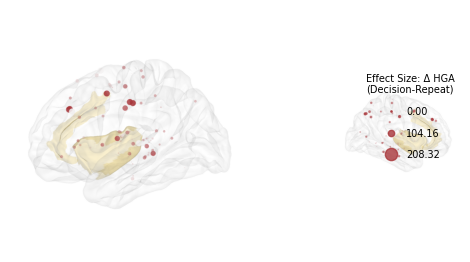

In [38]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)

# 使用显著数据进行可视化
cord = significant_delta[(significant_delta.phase=='response')][['x', 'y', 'z']].values
mean_delta = significant_delta[(significant_delta.phase=='response')]['delta'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# Color + size mapping
cmap = reds
max_abs = np.percentile(np.abs(mean_delta), 95)
max_abs = max(max_abs, 1e-6)
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

size_min, size_max = 1, 35
alpha_min, alpha_max = 0.2, 0.9

def val_to_size(v, vmax_abs, size_min, size_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return size_min + x * (size_max - size_min)

def val_to_alpha(v, vmax_abs, alpha_min, alpha_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return alpha_min + x * (alpha_max - alpha_min)

def build_valid_vertex_mask(labels, hemi, n_vertices):
    m = np.zeros(n_vertices, dtype=bool)
    for lab in labels:
        if lab.hemi == hemi:
            m[lab.vertices] = True
    return m

def add_projected_points(brain, hemi, coords, vals, tree, surf_coords, valid_vertex_mask):
    if coords.size == 0:
        return

    _, indices = tree.query(coords)
    projected = surf_coords[indices]
    keep = valid_vertex_mask[indices]

    if not keep.any():
        return

    for pt, v in zip(projected[keep], vals[keep]):
        cloud = pv.PolyData(pt.reshape(1, 3))
        color = cmap(norm(v))[:3]
        size = val_to_size(v, max_abs, size_min, size_max)
        alpha = val_to_alpha(v, max_abs, alpha_min, alpha_max)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=float(size),
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=float(alpha),
        )

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)
lh_valid_vertex = build_valid_vertex_mask(labels, 'lh', len(lh_coords_pial))

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)
rh_valid_vertex = build_valid_vertex_mask(labels, 'rh', len(rh_coords_pial))

if mask_lh.any():
    add_projected_points(
        lh_brain,
        'lh',
        cord[mask_lh],
        mean_delta[mask_lh],
        lh_tree,
        lh_coords_pial,
        lh_valid_vertex,
    )

if mask_rh.any():
    add_projected_points(
        rh_brain,
        'rh',
        cord[mask_rh],
        mean_delta[mask_rh],
        rh_tree,
        rh_coords_pial,
        rh_valid_vertex,
    )

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

acc_patterns = ['G_and_S_cingul-Mid-Ant','G_and_S_cingul-Mid-Ant',
                'G_and_S_cingul-Ant', 'G_and_S_cingul-Ant']

for lab in labels:
    if any(pattern in lab.name for pattern in acc_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)


for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [2.5, 1]})
# plt.subplots_adjust(wspace=0.02)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

example_values = [0, max_abs * 0.5, max_abs]
example_labels = ['0.00', f'{max_abs * 0.5:.2f}', f'{max_abs:.2f}']

legend_scale = 0.35

handles = []
for v, lab in zip(example_values, example_labels):
    # PyVista point_size 是像素；Matplotlib markersize 是 points
    ps_px = val_to_size(v, max_abs, size_min, size_max)
    ms_pt = ps_px * 72.0 / fig.dpi * legend_scale
    h = plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=red,
        markeredgecolor=red,
        markersize=max(1.0, ms_pt),
        alpha=0.8,
        label=lab,
    )
    handles.append(h)

ax2.legend(
    handles=handles,
    title='Effect Size: Δ HGA\n(Decision-Repeat)',
    loc='upper right',
    frameon=False,
    borderaxespad=0.2,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7,
)

lh_brain.close()
rh_brain.close()

# fig.savefig(f'../img/fig4/fig4_spatial_condition_difference.svg', dpi=300, bbox_inches='tight')

Most electrodes ROI: STG (n=22)


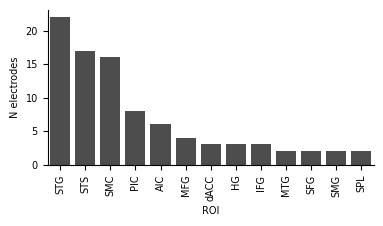

,roi,n_electrodes
10,STG,22
11,STS,17
7,SMC,16
5,PIC,8
0,AIC,6
3,MFG,4
12,dACC,3
1,HG,3
2,IFG,3
4,MTG,2


In [39]:
coords_ = significant_delta[(significant_delta.phase=='go') & (significant_delta.hemi=='L')]

roi_counts = (
    coords_[['roi', 'channel']]
    .dropna(subset=['roi', 'channel'])
    .drop_duplicates()
    .groupby('roi', as_index=False)
    .agg(n_electrodes=('channel', 'nunique'))
    .sort_values('n_electrodes', ascending=False)
)

max_roi = roi_counts.iloc[0]['roi']
max_n = int(roi_counts.iloc[0]['n_electrodes'])
print(f"Most electrodes ROI: {max_roi} (n={max_n})")

top_n = 15
roi_counts_plot = roi_counts.head(top_n)

fig, ax = plt.subplots(figsize=(10*cm, 6*cm))
ax = sns.barplot(
    data=roi_counts,
    x='roi',
    y='n_electrodes',
    order=roi_counts['roi'],
    color='0.3',
)
ax.set_xlabel('ROI', fontdict=fontdict)
ax.set_ylabel('N electrodes', fontdict=fontdict)
ax.tick_params(axis='x', rotation=90, labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
sns.despine()
plt.tight_layout()
plt.show()

# fig.savefig('../img/fig4/fig4_RT_roi_counts.svg', dpi=300, bbox_inches='tight')
roi_counts.head(20)

# Plot

In [88]:
subset = HGAs[
    (HGAs.roi.isin(['PIC','AIC','STG','SMC','dACC',
                    'ITG','SMG','MTG','IFG','SFG',
                    'MFG','STS','AG','SPL','IPL',
                    'HG']) 
    & (HGAs.task == 'LexicalDelay'))
]
subset.head()

,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
7,-1.000000,D0023_RPIF8-9,0.532667,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,59.983127,-31.909288,20.181224
10,-1.000000,D0023_RPIF9-10,0.181906,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,63.592048,-32.361872,20.761790
19,-0.992188,D0023_RPIF8-9,0.498545,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,59.983127,-31.909288,20.181224
22,-0.992188,D0023_RPIF9-10,0.158769,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,63.592048,-32.361872,20.761790
31,-0.984375,D0023_RPIF8-9,0.455962,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,59.983127,-31.909288,20.181224


In [49]:
import re

# load label array
phases = ['Stimulus', 'Delay', 'Go', 'Response']
conditions = ['Decision','Repeat']

epos = []

for phase in tqdm(phases):
    
    for sub in subset.subject.unique():
        
        picks = subset[subset.subject==sub].channel.unique().tolist()
        
        pt = BIDSPath(
            root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
            subject=sub,
            datatype='epoch(band)(zscore)',
            processing=phase,
            suffix='highgamma',
            extension='.h5',
            check=False
        )

        for condition in conditions:
            epo_path = pt.update(description=condition).match()[0]
            dc_epo = mne.read_epochs(epo_path, verbose='error')
            dc_epo.pick(picks)
            df = dc_epo.to_data_frame(long_format=True, verbose='error', scalings={'seeg': 1})
            # df['condition'] = df['condition'].str.extract(r'(Word|Nonword)/[^/]+')
            df['condition'] = df['condition'].str.split('/').str[2:4].str.join('/')
            df['description'] = condition
            df['phase'] = phase.lower()
            df['subject'] = sub
            epos.append(df)

epos = pd.concat(epos, ignore_index=True)
epos.head()

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [07:30<00:00, 112.53s/it]


,condition,epoch,time,channel,ch_type,value,description,phase,subject
0,Word/latin,1,-1.0,D0023_RPIF8-9,seeg,1.199449,Decision,stimulus,D0023
1,Word/latin,1,-1.0,D0023_RPIF9-10,seeg,-0.129328,Decision,stimulus,D0023
2,Word/latin,1,-1.0,D0023_R2IF1-2,seeg,-0.705476,Decision,stimulus,D0023
3,Word/latin,1,-1.0,D0023_R2MF10-11,seeg,-0.053457,Decision,stimulus,D0023
4,Word/latin,1,-1.0,D0023_R2MF9-10,seeg,-0.130285,Decision,stimulus,D0023


In [ ]:
agg = subset.groupby(['phase','description','channel','time','roi'], as_index=False)['value'].mean()

use_mask = (
    (agg['phase'].isin(['stimulus', 'delay']) & (agg['time'] > 0))
    | (agg['phase'].isin(['go', 'response']) & (agg['time'] < 0))
)

avg_hga = (
    agg.loc[use_mask]
    .groupby(['phase', 'description', 'channel','roi'], as_index=False)['value']
    .mean()
)

# subset = HGAs[HGAs.channel.isin(epos.channel)][['channel', 'hemi', 'roi', 'label','x','y','z']]
# subset.drop_duplicates(subset=['channel'], keep='first', inplace=True)
# avg_hga = avg_hga.merge(subset, on='channel', how='left')

# 按照ROI的平均value大小排序（针对go phase）
roi_avg_values = avg_hga[avg_hga.phase=='go'].groupby('roi')['value'].mean().sort_values(ascending=False)
roi_order = roi_avg_values.index.tolist()[::-1]

# 设置ROI为有序分类变量
avg_hga['roi'] = pd.Categorical(avg_hga['roi'], categories=roi_order, ordered=True)

avg_hga.head()

,phase,description,channel,roi,value
0,delay,Decision,D0023_RPIF8-9,AG,0.592618
1,delay,Decision,D0023_RPIF9-10,AG,0.186783
2,delay,Decision,D0024_LTG11-12,STG,-0.029848
3,delay,Decision,D0024_LTG12-13,STG,0.038283
4,delay,Decision,D0024_LTG14-15,STG,-0.116380


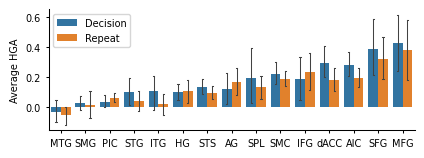

In [101]:
fig, ax = plt.subplots(figsize=(12*cm, 4*cm))

# 定义ROI的显示顺序
# roi_order.remove('IPL')
# pick_roi = ['MFG','SMC','dACC','IFG','AIC']
sns.barplot(
    data=avg_hga[(avg_hga.phase=='go')],
    x='roi',
    y='value',
    hue='description',
    # order=roi_order,  # 添加顺序控制
    lw=1.5, capsize=0.1,
    err_kws={'linewidth': .75},   
    ax=ax,
)

sns.despine()
ax.legend(fontsize=7)

ax.set_xlabel('')
ax.set_ylabel('Average HGA', fontsize=7)

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)

# The default network

In [27]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        'PhonemeSequence'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'
HGAs.head()

100%|██████████| 1140/1140 [00:20<00:00, 55.20it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0024_LTG14-15,0.007910,False,STG,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_temp_sup-Lateral,-66.294399,-28.103954,7.090004
1,-1.0,D0024_LTG8-9,-0.001315,False,Intersection,L,D0024,Decision,LexicalNoDelay,stimulus,sound,Intersection,-55.427594,-7.961854,2.275063
2,-1.0,D0024_LTG5-6,0.026363,False,SMC,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,-65.187402,-14.882005,13.114168
3,-1.0,D0024_LTG12-13,0.088550,False,STG,L,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_temp_sup-Lateral,-65.771716,-8.370915,-2.009006
4,-1.0,D0024_LTG15-26,0.011030,False,Intersection,L,D0024,Decision,LexicalNoDelay,stimulus,sound,Intersection,-58.577098,-13.150433,-14.837984


In [28]:
core_dmn_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Post', 'ctx_rh_G_and_S_cingul-Mid-Post',  
    'ctx_lh_G_precuneus', 'ctx_rh_G_precuneus',                           
    'ctx_lh_G_pariet_inf-Angular', 'ctx_rh_G_pariet_inf-Angular',         
    'ctx_lh_G_front_sup-medial', 'ctx_rh_G_front_sup-medial',            
    'ctx_lh_Pole_temporal', 'ctx_rh_Pole_temporal'                        
]
dmn_labels = core_dmn_labels

cords = HGAs[HGAs.label.isin(dmn_labels)]
cords = cords[['channel','subject','roi','hemi','label','x','y','z']].drop_duplicates()
cords.head()

,channel,subject,roi,hemi,label,x,y,z
0,D0029_LPSF2-3,D0029,PCC,L,ctx_lh_G_and_S_cingul-Mid-Post,-7.698863,-21.678610,38.387954
14,D0029_LPSF3-4,D0029,PCC,L,ctx_lh_G_and_S_cingul-Mid-Post,-9.415749,-22.942507,43.553899
2,D0029_RPMF1-2,D0029,PCC,R,ctx_rh_G_and_S_cingul-Mid-Post,8.971990,-14.980860,43.320253
7,D0029_LPMF1-2,D0029,PCC,L,ctx_lh_G_and_S_cingul-Mid-Post,-9.073478,-8.643116,40.006032
4,D0063_RAT8-9,D0063,TP,R,ctx_rh_Pole_temporal,39.183574,7.360997,-36.732678


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-20 10:53:18.097 (4423.610s) [    7FD49B5C5440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xdffce00): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-20 10:53:18.190 (4423.703s) [    7FD49B5C5440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xdffce00): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: eg

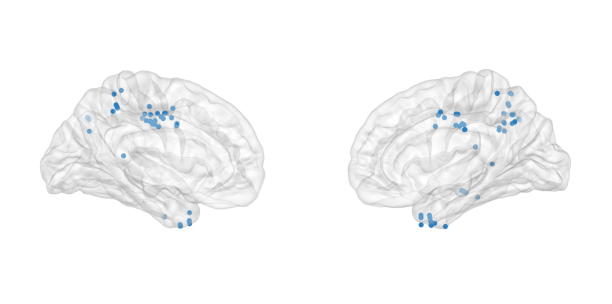

In [29]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree

lh_brain = Brain('fsaverage', subjects_dir=recon_dir, hemi='lh', surf='pial', background='white', show=False,
                 cortex=(0.9,0.9,0.9), alpha=0.3, size=(600*cm, 600*cm))
rh_brain = Brain('fsaverage', subjects_dir=recon_dir, hemi='rh', surf='pial', background='white', show=False,
                 cortex=(0.9,0.9,0.9), alpha=0.3, size=(600*cm, 600*cm))

cord = cords[['x', 'y', 'z']].values
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

lh_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_coords)
rh_tree = cKDTree(rh_coords)

color = plt.get_cmap('Blues')(0.7)[:3]
size = 25

# 直接使用原始坐标，不投影
if mask_lh.any():
    for pt in cord[mask_lh]:
        cloud = pv.PolyData(pt.reshape(1,3))
        lh_brain._renderer.plotter.add_mesh(cloud, render_points_as_spheres=True,
                                            point_size=size, color=color, lighting=False, opacity=1)

if mask_rh.any():
    for pt in cord[mask_rh]:
        cloud = pv.PolyData(pt.reshape(1,3))
        rh_brain._renderer.plotter.add_mesh(cloud, render_points_as_spheres=True,
                                            point_size=size, color=color, lighting=False, opacity=1)

for b in (lh_brain, rh_brain):
    b.show_view(view='medial', distance=400)
    b._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
ax1.imshow(lh_brain.screenshot(mode='rgb'))
ax1.axis('off')
ax2.imshow(rh_brain.screenshot(mode='rgb'))
ax2.axis('off')

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.show()

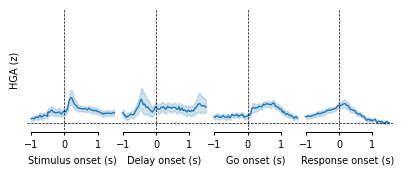

In [39]:
colors = [red, blue]

subset = HGAs[(HGAs.channel.isin(cords.channel.unique().tolist())) & (HGAs.roi.isin(cords.roi.unique().tolist()))]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
line1 = sns.lineplot(
    data=subset[(subset.phase == 'stimulus')
              ],
    x='time',
    y='value',
    # hue='roi',
    # hue_order=rois,
    ax=ax1,
    legend=True,
    lw=1
)

line2 = sns.lineplot(
    data=subset[(subset.phase == 'delay')
              ],
    x='time',
    y='value',
    # hue='roi',
    # hue_order=rois,
    ax=ax2,
    legend=False,
    lw=1
)

line3 = sns.lineplot(
    data=subset[(subset.phase == 'go')
              ],
    x='time',
    y='value',
    # hue='roi',
    # hue_order=rois,
    ax=ax3,
    legend=False,
    lw=1
)

line4 = sns.lineplot(
    data=subset[(subset.phase == 'response')],
    x='time',
    y='value',
    # hue='roi',
    # hue_order=rois,
    ax=ax4,
    legend=False,
    lw=1
)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

# plt.suptitle('roi: ' + rois[0] + ' in Lexical Delay', fontsize=7)
# plt.savefig('../img/fig1/fig1_AIPI_temporal_PictureNaming.svg', dpi=300, bbox_inches='tight')
plt.show()

# Salience before language network

In [10]:
HGAs.task.unique()

array(['LexicalNoDelay', 'LexicalDelay', 'PictureNaming', 'SentenceRep',
       'PhonemeSequence'], dtype=object)

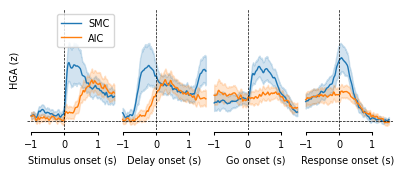

In [17]:
colors = [red, blue]
rois = ['AIC','SMC']

subset = HGAs[
    (HGAs.modality == 'sound')
    & (~HGAs.task.isin(['LexicalNoDelay'])) 
    & (HGAs.roi.isin(rois))
    # & (HGAs.hemi=='L')
    & (HGAs.description=='Decision')
]
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

for (ax, phase) in zip(fig.axes, ['stimulus', 'delay', 'go', 'response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    
    line = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='roi',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    ax.set_ylim(-0.1, 1.2)


for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

# plt.suptitle(rois[0] + ' in Lexical Delay', fontsize=7)
# plt.savefig(f'../img/fig4/fig4_{rois[0]}_condition_difference.svg', dpi=300, bbox_inches='tight')

plt.show()